# 06 - Statistical Baseline: train, evaluate, tune (Days 11-12)

**Day 11**: logistic regression on the Day-10 features; macro-F1, precision, recall, confusion matrix.
**Day 12**: class weighting on/off, linear SVM comparison, stratified 5-fold CV, lock the number.

Hunter asked for the within-dataset figure as **mean +/- std over 5 folds**, not a single split,
so the locked number below carries a variance estimate.

### Setup

In [1]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e:
    print('Not on Colab / already mounted:', e)

Not on Colab / already mounted: No module named 'google.colab'


In [2]:
import sys; sys.path.insert(0, '/content/drive/MyDrive/dissertation/notebooks')
from hinglish_hate import (load_bohra, load_hasoc2021, load_hasoc2022_threads,
                           filter_romanised, load_lexicon)
from hinglish_hate.baseline import (build_full_pipeline, evaluate_pipeline,
                                    cross_validate_macro_f1, build_pipeline)
from sklearn.model_selection import train_test_split
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
DATA_ROOT = Path(r'C:\Users\LENOVO\Desktop\dissertation\data')
FIG_DIR   = Path('/content/drive/MyDrive/dissertation/writing/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
def find_one(root,name):
    h=list(Path(root).rglob(name))
    if not h: raise FileNotFoundError(name)
    return h[0]
def savefig(n):
    plt.savefig(FIG_DIR/n, dpi=150, bbox_inches='tight'); print('saved', FIG_DIR/n)

### Load data, lexicon, and the Day-10 split

In [3]:
bohra   = load_bohra(find_one(DATA_ROOT,'hate_speech.tsv'))
bohra_r = filter_romanised(bohra)

lex_csv = DATA_ROOT/'hinglish_slur_lexicon.csv'
terms = load_lexicon(lex_csv) if lex_csv.exists() else load_lexicon(find_one(DATA_ROOT,'hate_lexicon.txt'))
print(f'{len(terms)} lexicon surface forms')

split = DATA_ROOT/'splits'
if (split/'bohra_train.parquet').exists():
    tr = pd.read_parquet(split/'bohra_train.parquet'); te = pd.read_parquet(split/'bohra_test.parquet')
    X_train, y_train = tr['text'].tolist(), tr['label'].tolist()
    X_test,  y_test  = te['text'].tolist(), te['label'].tolist()
    print('loaded saved Day-10 split')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        bohra_r['text'].tolist(), bohra_r['label'].tolist(),
        test_size=0.2, stratify=bohra_r['label'], random_state=42)
    print('rebuilt split')
print(f'train {len(X_train)} | test {len(X_test)}')

[load_bohra] 4574 rows | fixed 0 label typo(s) | dropped 4 unparseable
1219 lexicon surface forms
loaded saved Day-10 split
train 3659 | test 915


## Day 11 - Train the baseline and report

In [4]:
res = evaluate_pipeline(build_full_pipeline(terms, clf='logreg', class_weight='balanced'),
                       X_train, y_train, X_test, y_test)
print(f"macro-F1 = {res['macro_f1']:.3f}   hate-F1 = {res['hate_f1']:.3f}   acc = {res['accuracy']:.3f}")
print()
print(res['report'])

macro-F1 = 0.642   hate-F1 = 0.555   acc = 0.663

              precision    recall  f1-score   support

         not      0.748     0.712     0.729       583
        hate      0.533     0.578     0.555       332

    accuracy                          0.663       915
   macro avg      0.641     0.645     0.642       915
weighted avg      0.670     0.663     0.666       915



### Confusion matrix

saved \content\drive\MyDrive\dissertation\writing\figures\baseline_confusion_matrix.png


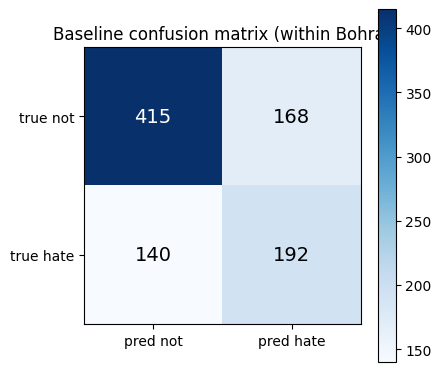

In [5]:
cm = res['confusion']
fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1], ['pred not','pred hate']); ax.set_yticks([0,1], ['true not','true hate'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
ax.set_title('Baseline confusion matrix (within Bohra)')
plt.colorbar(im); plt.tight_layout(); savefig('baseline_confusion_matrix.png'); plt.show()

## Day 12 - Tuning: class weighting, SVM, feature ablation

Four comparisons that answer distinct questions:
- **class_weight** balanced vs none: what does ignoring the imbalance cost?
- **LogReg vs LinearSVM**: is a different linear model better?
- **word-only vs word+char+lexicon**: how much do the Day-10 features actually add?

In [6]:
rows=[]
for clf in ['logreg','svm']:
    for cw in ['balanced', None]:
        r = evaluate_pipeline(build_full_pipeline(terms, clf=clf, class_weight=cw),
                              X_train, y_train, X_test, y_test)
        rows.append({'model':clf, 'class_weight':str(cw), 'macro_f1':round(r['macro_f1'],3),
                     'hate_P':round(r['precision_hate'],3), 'hate_R':round(r['recall_hate'],3),
                     'hate_F1':round(r['hate_f1'],3), 'acc':round(r['accuracy'],3)})

# word-only reference (the original Day-1..10 baseline)
wr = build_pipeline()
wr.fit(X_train, y_train)
from sklearn.metrics import f1_score
rows.append({'model':'logreg (word-only)','class_weight':'balanced',
             'macro_f1':round(f1_score(y_test, wr.predict(X_test), average='macro'),3),
             'hate_P':np.nan,'hate_R':np.nan,'hate_F1':np.nan,'acc':np.nan})

comp = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(comp)

,model,class_weight,macro_f1,hate_P,hate_R,hate_F1,acc
0,logreg,balanced,0.642,0.533,0.578,0.555,0.663
1,svm,balanced,0.630,0.531,0.521,0.526,0.659
2,logreg (word-only),balanced,0.629,NaN,NaN,NaN,NaN
3,svm,None,0.619,0.533,0.467,0.498,0.658
4,logreg,None,0.617,0.621,0.355,0.452,0.687


### C sweep on the best model

Regularisation strength. Wide sweep, single split, just to check the default is not far off.

In [7]:
best_clf = comp.iloc[0]['model'] if 'word-only' not in comp.iloc[0]['model'] else 'logreg'
sweep=[]
for C in [0.1, 0.5, 1.0, 2.0, 5.0]:
    r = evaluate_pipeline(build_full_pipeline(terms, clf=best_clf, C=C, class_weight='balanced'),
                          X_train, y_train, X_test, y_test)
    sweep.append({'C':C, 'macro_f1':round(r['macro_f1'],3)})
sweep=pd.DataFrame(sweep); display(sweep)
best_C = float(sweep.loc[sweep['macro_f1'].idxmax(),'C'])
print('best C =', best_C, '| model =', best_clf)

,C,macro_f1
0,0.1,0.653
1,0.5,0.653
2,1.0,0.642
3,2.0,0.631
4,5.0,0.626


best C = 0.1 | model = logreg


## Lock the number: stratified 5-fold CV

The headline within-dataset figure, as Hunter asked: **mean +/- std of macro-F1 across 5 stratified
folds** on the full romanised Bohra set. This is the number to quote and to compare every later
model against.

In [8]:
final_pipe = build_full_pipeline(terms, clf=best_clf, C=best_C, class_weight='balanced')
cv = cross_validate_macro_f1(final_pipe, bohra_r['text'].tolist(), bohra_r['label'].tolist(), n_splits=5)
print('per-fold macro-F1:', [round(s,3) for s in cv['scores']])
print()
print(f"LOCKED BASELINE:  macro-F1 = {cv['mean']:.3f} +/- {cv['std']:.3f}  (5-fold, romanised Bohra)")
print(f"  model = {best_clf}, C = {best_C}, class_weight = balanced")
print(f"  features = word(1,2) + char_wb(3,5) TF-IDF + lexicon count/ratio ({len(terms)} forms)")

per-fold macro-F1: [np.float64(0.665), np.float64(0.641), np.float64(0.65), np.float64(0.652), np.float64(0.663)]

LOCKED BASELINE:  macro-F1 = 0.654 +/- 0.009  (5-fold, romanised Bohra)
  model = logreg, C = 0.1, class_weight = balanced
  features = word(1,2) + char_wb(3,5) TF-IDF + lexicon count/ratio (1219 forms)


### Save the results table for the write-up

In [9]:
summary = comp.copy()
summary.to_csv(FIG_DIR.parent/'baseline_results.csv', index=False)
pd.DataFrame({'fold':range(1,len(cv['scores'])+1),'macro_f1':cv['scores']}).to_csv(
    FIG_DIR.parent/'baseline_cv_folds.csv', index=False)
print('saved baseline_results.csv and baseline_cv_folds.csv to writing/')

saved baseline_results.csv and baseline_cv_folds.csv to writing/


### Notes
- Report the CV mean +/- std as the headline, and keep the single-split confusion matrix as the
  illustrative error breakdown.
- If `class_weight=None` scores close to `balanced`, say so explicitly: it means the imbalance is
  mild enough that weighting is a small correction, which is a finding, not a failure.
- The word-only row is the honest ablation: it isolates how much the char n-grams and lexicon add
  over the original TF-IDF baseline. Quote both numbers in the dissertation.
- Every later model (XLM-R, IndicBERT, MuRIL, LoRA LLM) must be scored on this same split and the
  same CV protocol, or the comparison is not like-for-like.